##load


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

cols = [
    "erythema", "scaling", "definite_borders", "itching", "koebner_phenomenon",
    "polygonal_papules", "follicular_papules", "oral_mucosal_involvement",
    "knee_elbow_involvement", "scalp_involvement", "family_history",
    "melanin_incontinence", "eosinophils_infiltrate", "pnl_infiltrate",
    "fibrosis_papillary_dermis", "exocytosis", "acanthosis", "hyperkeratosis",
    "parakeratosis", "clubbing_rete_ridges", "elongation_rete_ridges",
    "thinning_suprapapillary_epidermis", "spongiform_pustule", "munro_microabcess",
    "focal_hypergranulosis", "disappearance_granular_layer",
    "vacuolisation_damage_basal_layer", "spongiosis", "saw_tooth_appearance_retes",
    "follicular_horn_plug", "perifollicular_parakeratosis",
    "inflammatory_mononuclear_infiltrate", "band_like_infiltrate",
    "age", "class"
]

URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/dermatology/dermatology.data"

try:
    df = pd.read_csv(URL, header=None, names=cols, na_values="?")
except Exception as e:
    print("Direct download failed, using ucimlrepo fallback:", e)
    from ucimlrepo import fetch_ucirepo   # if missing, run:  !pip install -q ucimlrepo
    d = fetch_ucirepo(id=33)
    df = pd.concat([d.data.features, d.data.targets], axis=1)
    df.columns = cols

class_names = {1: "psoriasis", 2: "seboreic dermatitis", 3: "lichen planus",
               4: "pityriasis rosea", 5: "chronic dermatitis", 6: "pityriasis rubra pilaris"}

print("Shape:", df.shape)
df.head()

Shape: (366, 35)


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_infiltrate,pnl_infiltrate,fibrosis_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_rete_ridges,elongation_rete_ridges,thinning_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,3,0,0,0,1,0,55.0,2
1,3,3,3,2,1,0,0,0,1,1,1,0,0,1,0,1,2,0,2,2,2,2,2,1,0,0,0,0,0,0,0,1,0,8.0,1
2,2,1,2,3,1,3,0,3,0,0,0,1,0,0,0,1,2,0,2,0,0,0,0,0,2,0,2,3,2,0,0,2,3,26.0,3
3,2,2,2,0,0,0,0,0,3,2,0,0,0,3,0,0,2,0,3,2,2,2,2,0,0,3,0,0,0,0,0,3,0,40.0,1
4,2,3,2,2,2,2,0,2,0,0,0,1,0,0,0,1,2,0,0,0,0,0,0,0,2,2,3,2,3,0,0,2,3,45.0,3


In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
erythema,366.0,2.068306,0.664753,0.0,2.0,2.0,2.00,3.0
scaling,366.0,1.795082,0.701527,0.0,1.0,2.0,2.00,3.0
definite_borders,366.0,1.549180,0.907525,0.0,1.0,2.0,2.00,3.0
itching,366.0,1.366120,1.138299,0.0,0.0,1.0,2.00,3.0
koebner_phenomenon,366.0,0.633880,0.908016,0.0,0.0,0.0,1.00,3.0
polygonal_papules,366.0,0.448087,0.957327,0.0,0.0,0.0,0.00,3.0
follicular_papules,366.0,0.166667,0.570588,0.0,0.0,0.0,0.00,3.0
oral_mucosal_involvement,366.0,0.377049,0.834147,0.0,0.0,0.0,0.00,3.0
knee_elbow_involvement,366.0,0.614754,0.982979,0.0,0.0,0.0,1.00,3.0
scalp_involvement,366.0,0.519126,0.905639,0.0,0.0,0.0,1.00,3.0


In [3]:
print("Missing values per column (non-zero only):")
print(df.isna().sum()[df.isna().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())

# --- Handle missing values: only `age` has them (8 records) -> impute with median
df["age"] = df["age"].fillna(df["age"].median())

# --- Handle duplicates
df = df.drop_duplicates().reset_index(drop=True)

# --- Outliers: all features except `age` are ordinal 0-3 (and family_history 0/1),
#     so an IQR check is only meaningful for `age`.
q1, q3 = df["age"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
mask = (df["age"] < low) | (df["age"] > high)
print(f"\nAge IQR bounds: [{low:.1f}, {high:.1f}] -> {mask.sum()} flagged points")
print("These are clinically plausible ages, so they are kept (not errors).")

print("\nFinal shape:", df.shape, "| remaining missing:", int(df.isna().sum().sum()))

Missing values per column (non-zero only):
age    8
dtype: int64

Duplicate rows: 0

Age IQR bounds: [-9.5, 82.5] -> 0 flagged points
These are clinically plausible ages, so they are kept (not errors).

Final shape: (366, 35) | remaining missing: 0


### Visualisation

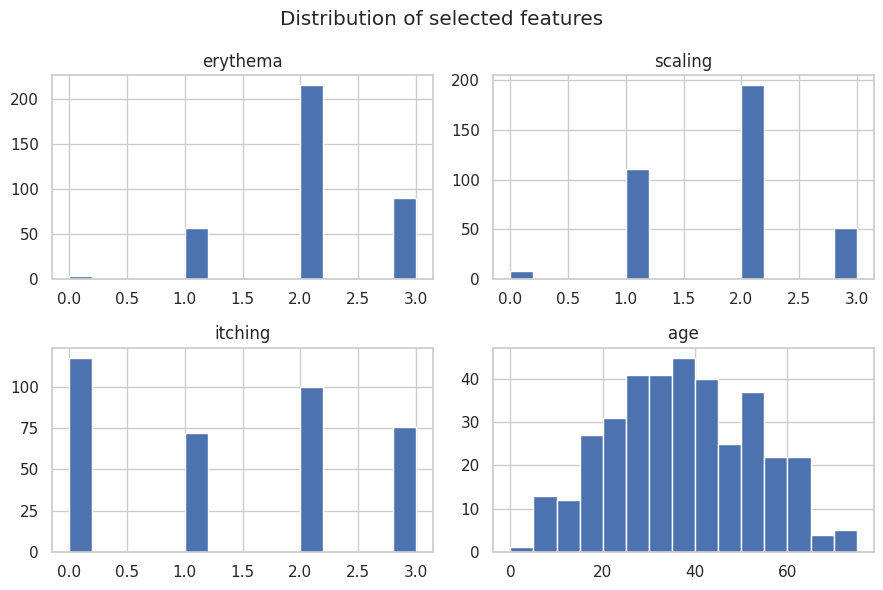

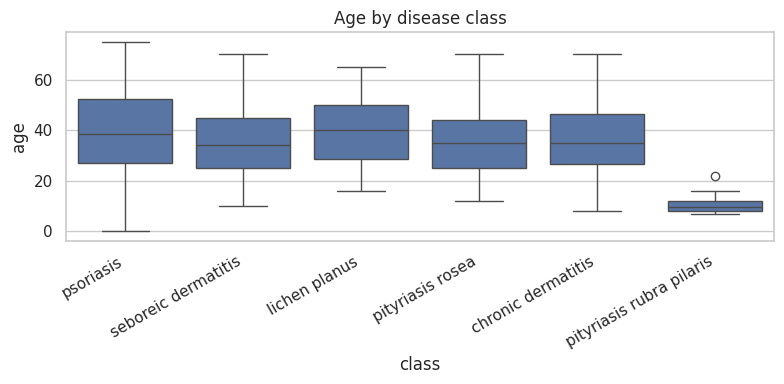

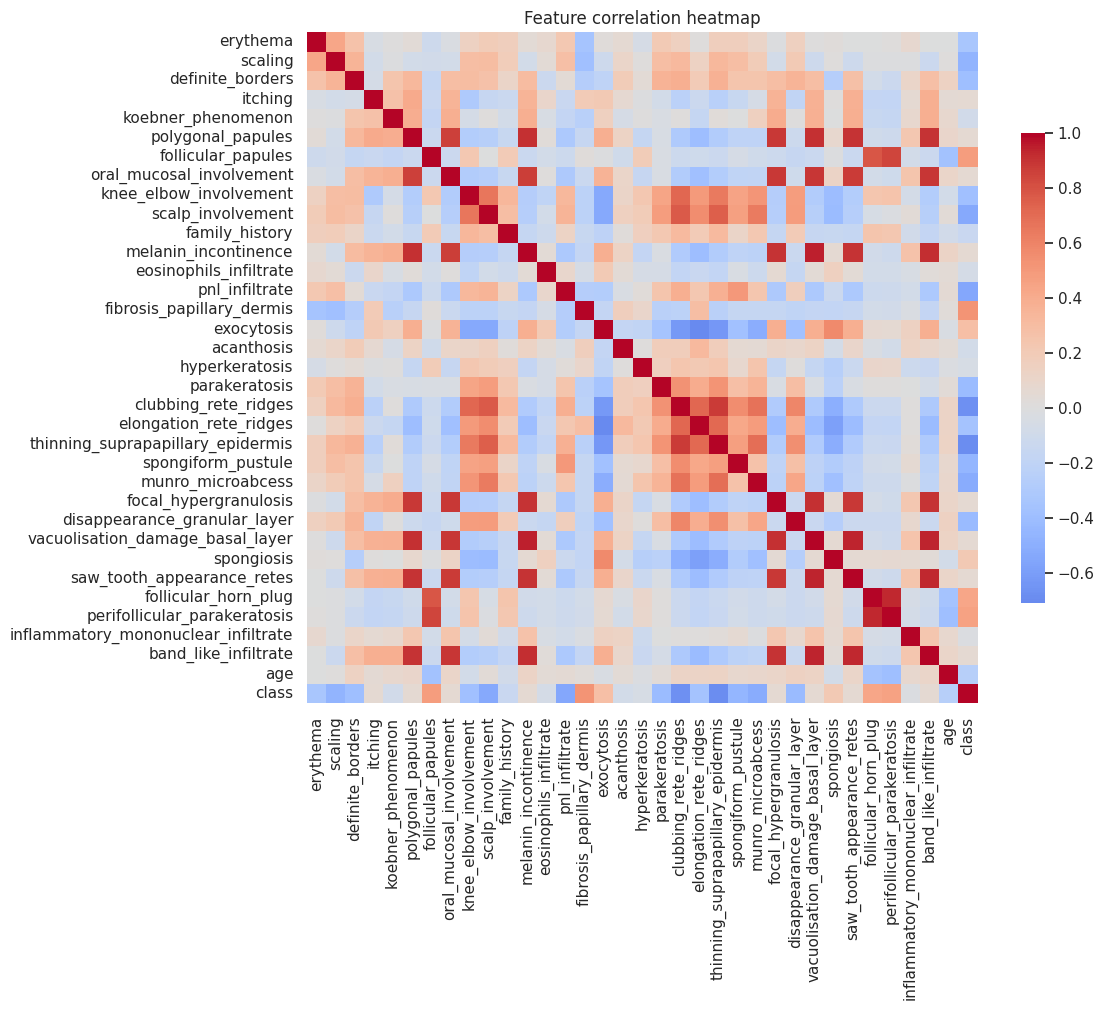

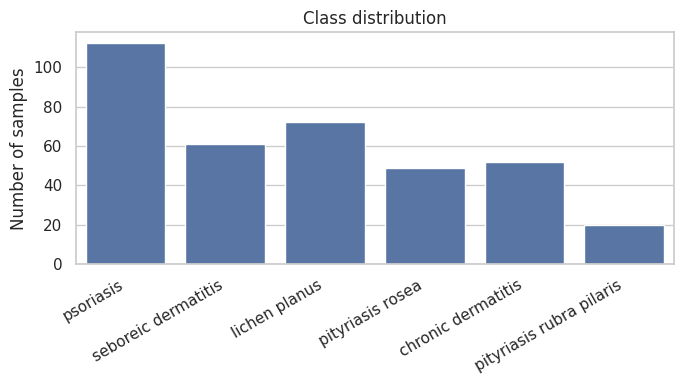

                          count  percent
class                                   
psoriasis                   112     30.6
seboreic dermatitis          61     16.7
lichen planus                72     19.7
pityriasis rosea             49     13.4
chronic dermatitis           52     14.2
pityriasis rubra pilaris     20      5.5


In [4]:
# Histograms of a few representative features
df[["erythema", "scaling", "itching", "age"]].hist(figsize=(9, 6), bins=15, layout=(2, 2))
plt.suptitle("Distribution of selected features")
plt.tight_layout()
plt.show()

# Box plot of age across the six disease classes
plt.figure(figsize=(8, 4))
sns.boxplot(x="class", y="age", data=df)
plt.xticks(range(6), [class_names[i] for i in range(1, 7)], rotation=30, ha="right")
plt.title("Age by disease class")
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.7}, xticklabels=True, yticklabels=True)
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

# Class distribution
counts = df["class"].value_counts().sort_index()
plt.figure(figsize=(7, 4))
sns.barplot(x=[class_names[i] for i in counts.index], y=counts.values)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Number of samples")
plt.title("Class distribution")
plt.tight_layout()
plt.show()

print(pd.DataFrame({"count": counts, "percent": (100 * counts / len(df)).round(1)})
      .rename(index=class_names))

## Preprocessing

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

X = df.drop(columns="class")
y_raw = df["class"]

# --- Encode the target (1..6 -> 0..5)
le = LabelEncoder()
y = le.fit_transform(y_raw)
target_names = [class_names[c] for c in le.classes_]
print("Encoding:", dict(zip(le.classes_, range(len(le.classes_)))))

# --- Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

# --- Standardise features (fit on train only, to avoid leakage)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("\nTrain class counts:", np.bincount(y_train))
print("Test  class counts:", np.bincount(y_test))

Encoding: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3, np.int64(5): 4, np.int64(6): 5}
Train: (292, 34)  Test: (74, 34)

Train class counts: [89 49 57 39 42 16]
Test  class counts: [23 12 15 10 10  4]


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score,
                             precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN (k=5)":           KNeighborsClassifier(n_neighbors=5),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM (RBF)":           SVC(kernel="rbf", probability=True, random_state=42),
}

rows, preds, probas = [], {}, {}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)
    preds[name], probas[name] = y_pred, y_prob

    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
    rows.append({
        "Model": name,
        "Train acc": accuracy_score(y_train, model.predict(X_train_s)),
        "Test acc": accuracy_score(y_test, y_pred),
        "Gap": accuracy_score(y_train, model.predict(X_train_s)) - accuracy_score(y_test, y_pred),
        "Precision (macro)": p,
        "Recall (macro)": r,
        "F1 (macro)": f1,
        "AUC (OvR macro)": roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro"),
    })

results = pd.DataFrame(rows).set_index("Model").round(3).sort_values("Test acc", ascending=False)
print("Test set size:", len(y_test), "samples -> one error moves accuracy by",
      round(100 / len(y_test), 2), "percentage points\n")
results

Test set size: 74 samples -> one error moves accuracy by 1.35 percentage points



,Train acc,Test acc,Gap,Precision (macro),Recall (macro),F1 (macro),AUC (OvR macro)
Model,,,,,,,
SVM (RBF),0.983,0.973,0.010,0.972,0.972,0.970,0.998
Logistic Regression,0.997,0.959,0.037,0.962,0.961,0.957,0.999
Random Forest,1.000,0.959,0.041,0.955,0.956,0.954,0.999
KNN (k=5),0.973,0.905,0.067,0.907,0.909,0.903,0.986


In [7]:
for name, y_pred in preds.items():
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

Logistic Regression
                          precision    recall  f1-score   support

               psoriasis       1.00      1.00      1.00        23
     seboreic dermatitis       1.00      0.83      0.91        12
           lichen planus       1.00      0.93      0.97        15
        pityriasis rosea       0.77      1.00      0.87        10
      chronic dermatitis       1.00      1.00      1.00        10
pityriasis rubra pilaris       1.00      1.00      1.00         4

                accuracy                           0.96        74
               macro avg       0.96      0.96      0.96        74
            weighted avg       0.97      0.96      0.96        74

KNN (k=5)
                          precision    recall  f1-score   support

               psoriasis       1.00      0.96      0.98        23
     seboreic dermatitis       0.80      0.67      0.73        12
           lichen planus       1.00      0.93      0.97        15
        pityriasis rosea       0.64      0

### Confusion matrices

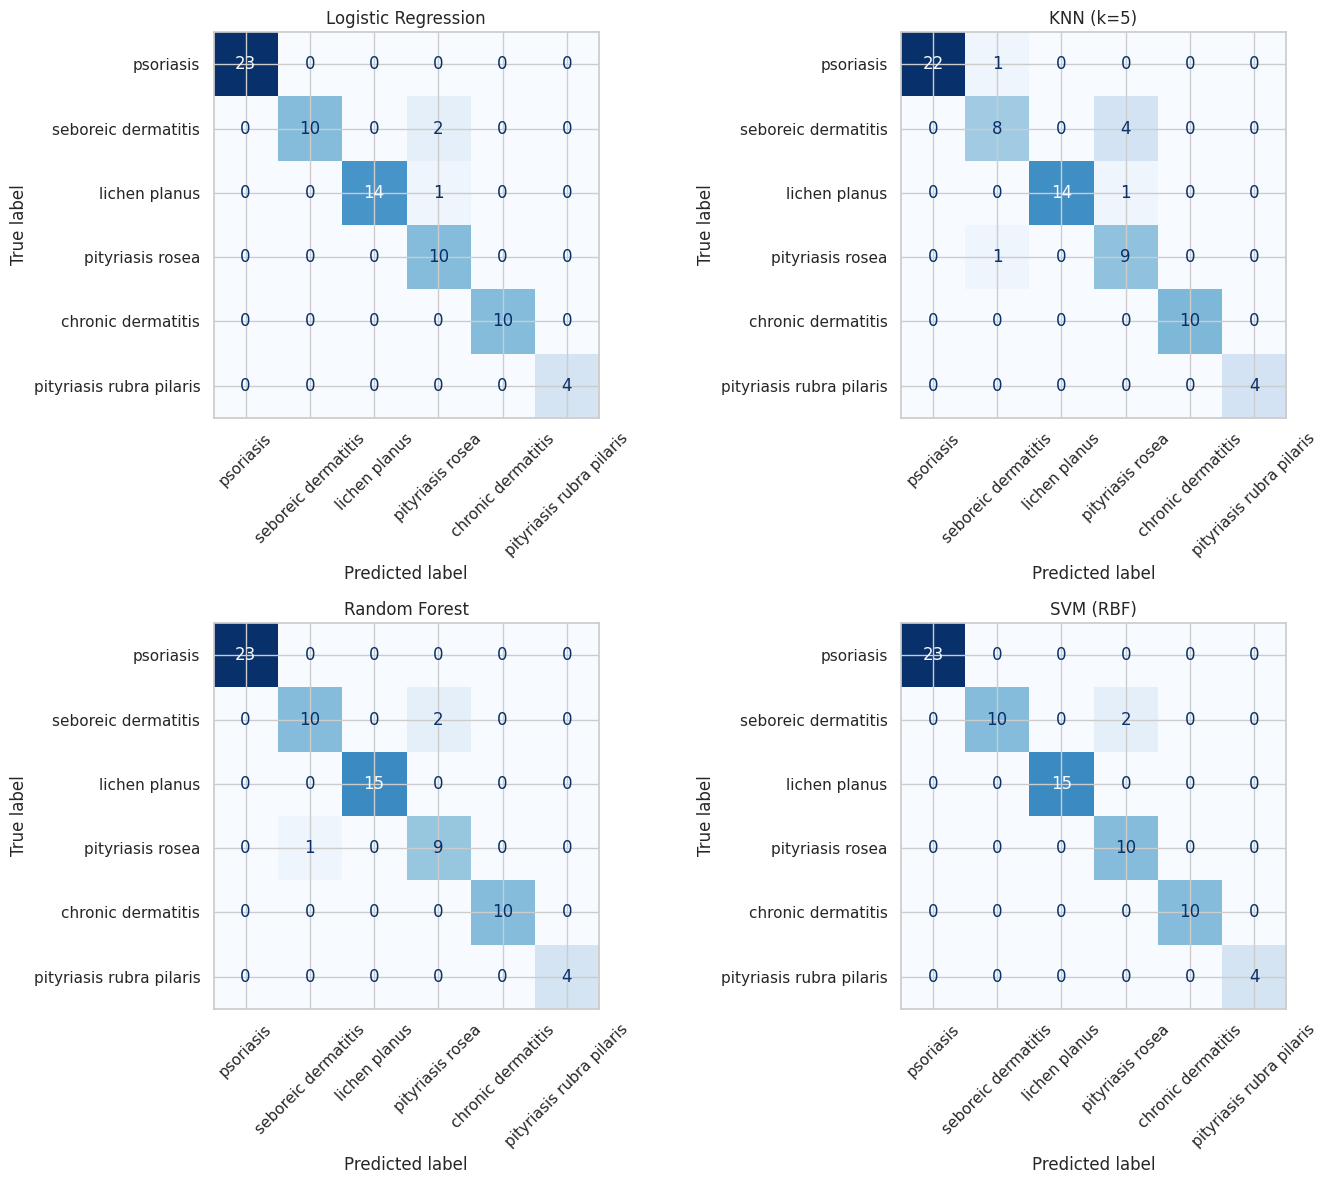

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (name, y_pred) in zip(axes.ravel(), preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=target_names).plot(
        ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
    ax.set_title(name)

plt.tight_layout()
plt.show()

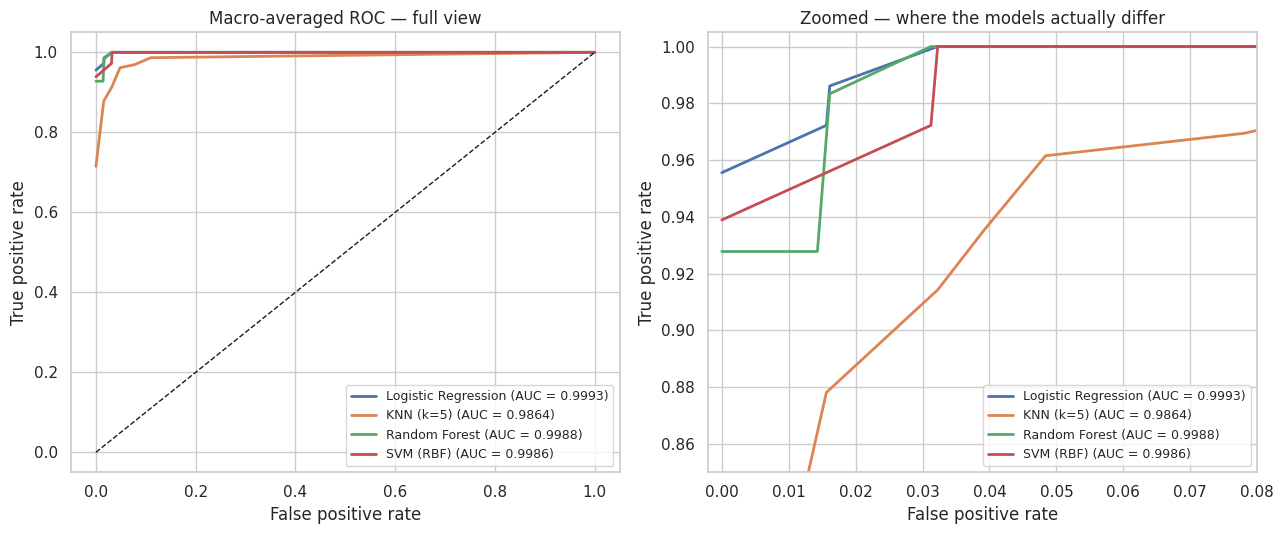

In [9]:
y_test_bin = label_binarize(y_test, classes=np.arange(len(target_names)))

def macro_roc(y_bin, y_prob):
    fprs, tprs = [], []
    for i in range(y_bin.shape[1]):
        f, t, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        fprs.append(f)
        tprs.append(t)
    grid = np.unique(np.concatenate(fprs))
    mean_tpr = np.zeros_like(grid)
    for f, t in zip(fprs, tprs):
        mean_tpr += np.interp(grid, f, t)
    mean_tpr /= y_bin.shape[1]
    return grid, mean_tpr, auc(grid, mean_tpr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, zoom in zip(axes, [False, True]):
    for name, y_prob in probas.items():
        fpr, tpr, a = macro_roc(y_test_bin, y_prob)
        ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {a:.4f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    if zoom:
        ax.set_xlim(-0.002, 0.08)
        ax.set_ylim(0.85, 1.005)
        ax.set_title("Zoomed — where the models actually differ")
    else:
        ax.set_title("Macro-averaged ROC — full view")
    ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

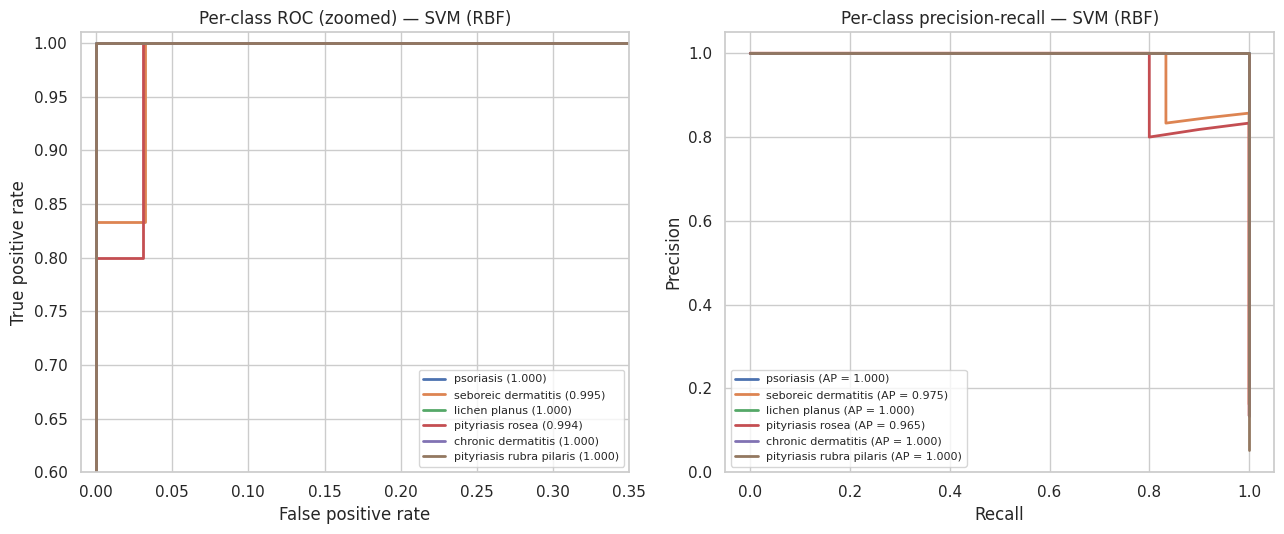

Macro average precision: 0.9901


In [10]:
# Per-class ROC for the best model, plus precision-recall curves.
# PR curves are more informative than ROC when classes are imbalanced, because
# they ignore true negatives (which dominate in one-vs-rest).
best = results["Test acc"].idxmax()
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for i, cname in enumerate(target_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probas[best][:, i])
    axes[0].plot(fpr, tpr, lw=2, label=f"{cname} ({auc(fpr, tpr):.3f})")

    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], probas[best][:, i])
    ap = average_precision_score(y_test_bin[:, i], probas[best][:, i])
    axes[1].plot(rec, prec, lw=2, label=f"{cname} (AP = {ap:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlim(-0.01, 0.35)
axes[0].set_ylim(0.6, 1.01)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title(f"Per-class ROC (zoomed) — {best}")
axes[0].legend(loc="lower right", fontsize=8)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_ylim(0.0, 1.05)
axes[1].set_title(f"Per-class precision-recall — {best}")
axes[1].legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()

print("Macro average precision:",
      round(average_precision_score(y_test_bin, probas[best], average="macro"), 4))

In [11]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score, cross_validate

pipes = {name: Pipeline([("scaler", StandardScaler()), ("clf", clone(m))])
         for name, m in models.items()}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

cv_rows = []
for name, pipe in pipes.items():
    out = cross_validate(pipe, X, y, cv=cv, n_jobs=-1,
                         scoring=["accuracy", "f1_macro"], return_train_score=True)
    cv_rows.append({
        "Model": name,
        "CV train acc": out["train_accuracy"].mean(),
        "CV test acc": out["test_accuracy"].mean(),
        "CV test std": out["test_accuracy"].std(),
        "Gap": out["train_accuracy"].mean() - out["test_accuracy"].mean(),
        "CV F1 (macro)": out["test_f1_macro"].mean(),
    })

cv_results = pd.DataFrame(cv_rows).set_index("Model").round(4).sort_values("CV test acc", ascending=False)
print("25 folds (5-fold x 5 repeats), scaler fitted inside each fold\n")
cv_results

25 folds (5-fold x 5 repeats), scaler fitted inside each fold



,CV train acc,CV test acc,CV test std,Gap,CV F1 (macro)
Model,,,,,
SVM (RBF),0.9876,0.9732,0.0179,0.0143,0.9709
Random Forest,1.0000,0.9716,0.0182,0.0284,0.9671
Logistic Regression,0.9993,0.9710,0.0170,0.0283,0.9679
KNN (k=5),0.9727,0.9585,0.0207,0.0142,0.9565


### 3b.2 Learning curves

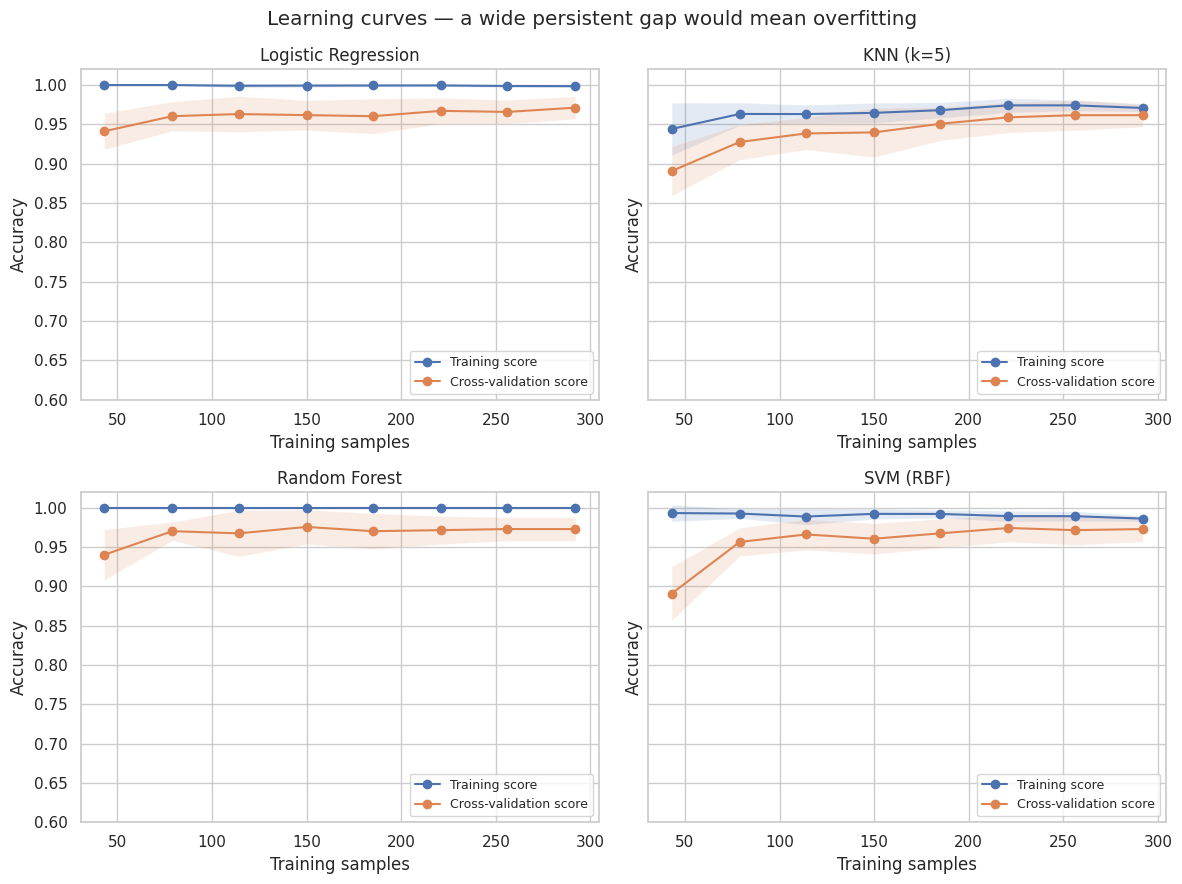

In [12]:
from sklearn.model_selection import learning_curve

cv5 = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=0)
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)

for ax, (name, pipe) in zip(axes.ravel(), pipes.items()):
    sizes, train_sc, val_sc = learning_curve(
        pipe, X, y, cv=cv5, scoring="accuracy", n_jobs=-1,
        train_sizes=np.linspace(0.15, 1.0, 8), shuffle=True, random_state=42)

    ax.plot(sizes, train_sc.mean(axis=1), "o-", label="Training score")
    ax.fill_between(sizes, train_sc.mean(1) - train_sc.std(1),
                    train_sc.mean(1) + train_sc.std(1), alpha=0.15)
    ax.plot(sizes, val_sc.mean(axis=1), "o-", label="Cross-validation score")
    ax.fill_between(sizes, val_sc.mean(1) - val_sc.std(1),
                    val_sc.mean(1) + val_sc.std(1), alpha=0.15)
    ax.set_title(name)
    ax.set_xlabel("Training samples")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.6, 1.02)
    ax.legend(loc="lower right", fontsize=9)

plt.suptitle("Learning curves — a wide persistent gap would mean overfitting")
plt.tight_layout()
plt.show()

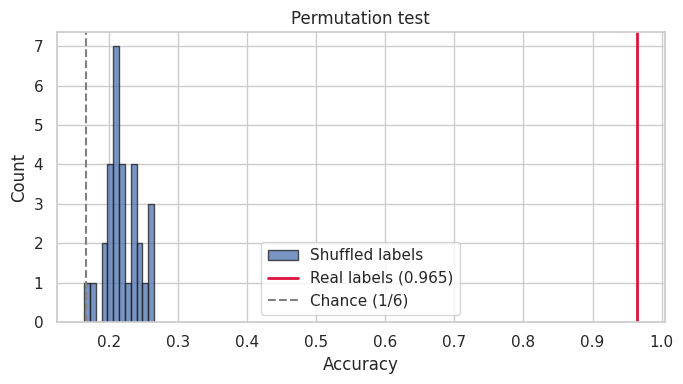

Real accuracy      : 0.9646
Shuffled mean      : 0.2198  (chance = 0.1667)
p-value            : 0.0323

Shuffled labels land at chance -> the signal is in the features, not a leak.


In [13]:
from sklearn.model_selection import permutation_test_score

cv_perm = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=1)
real_score, perm_scores, pvalue = permutation_test_score(
    pipes["Logistic Regression"], X, y, cv=cv_perm,
    n_permutations=30, scoring="accuracy", n_jobs=-1, random_state=42)

plt.figure(figsize=(7, 4))
plt.hist(perm_scores, bins=12, edgecolor="k", alpha=0.75, label="Shuffled labels")
plt.axvline(real_score, color="crimson", lw=2, label=f"Real labels ({real_score:.3f})")
plt.axvline(1 / len(target_names), color="grey", ls="--", lw=1.5, label="Chance (1/6)")
plt.xlabel("Accuracy")
plt.ylabel("Count")
plt.title("Permutation test")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Real accuracy      : {real_score:.4f}")
print(f"Shuffled mean      : {perm_scores.mean():.4f}  (chance = {1/len(target_names):.4f})")
print(f"p-value            : {pvalue:.4f}")
print("\nShuffled labels land at chance -> the signal is in the features, not a leak.")

In [14]:
from sklearn.model_selection import GridSearchCV

grids = {
    "Logistic Regression": (LogisticRegression(max_iter=5000),
                            {"clf__C": [0.01, 0.1, 1, 10, 100]}),
    "KNN":                 (KNeighborsClassifier(),
                            {"clf__n_neighbors": [3, 5, 7, 9, 11],
                             "clf__weights": ["uniform", "distance"],
                             "clf__metric": ["euclidean", "manhattan"]}),
    "Random Forest":       (RandomForestClassifier(random_state=42),
                            {"clf__n_estimators": [200, 400],
                             "clf__max_depth": [None, 10],
                             "clf__min_samples_leaf": [1, 2]}),
    "SVM (RBF)":           (SVC(kernel="rbf", probability=True, random_state=42),
                            {"clf__C": [0.1, 1, 10, 100],
                             "clf__gamma": ["scale", 0.01, 0.1]}),
}

inner_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=7)
tuned, tuned_rows = {}, []

for name, (est, grid) in grids.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", est)])
    gs = GridSearchCV(pipe, grid, cv=inner_cv, scoring="f1_macro", n_jobs=-1)
    gs.fit(X_train, y_train)          # unscaled: the pipeline scales internally
    tuned[name] = gs.best_estimator_

    y_pred = gs.predict(X_test)
    y_prob = gs.predict_proba(X_test)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
    tuned_rows.append({
        "Model": name,
        "Best params": str(gs.best_params_).replace("clf__", ""),
        "CV F1 (inner)": gs.best_score_,
        "Test acc": accuracy_score(y_test, y_pred),
        "Test F1 (macro)": f1,
        "Test AUC": roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro"),
    })

tuned_results = pd.DataFrame(tuned_rows).set_index("Model").round(4)
tuned_results

,Best params,CV F1 (inner),Test acc,Test F1 (macro),Test AUC
Model,,,,,
Logistic Regression,{'C': 0.1},0.9748,0.9459,0.9422,0.9988
KNN,"{'metric': 'manhattan', 'n_neighbors': 7, 'wei...",0.9766,0.9324,0.9241,0.9886
Random Forest,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es...",0.9691,0.9730,0.9694,0.9981
SVM (RBF),"{'C': 1, 'gamma': 0.01}",0.9769,0.9595,0.9545,0.9983


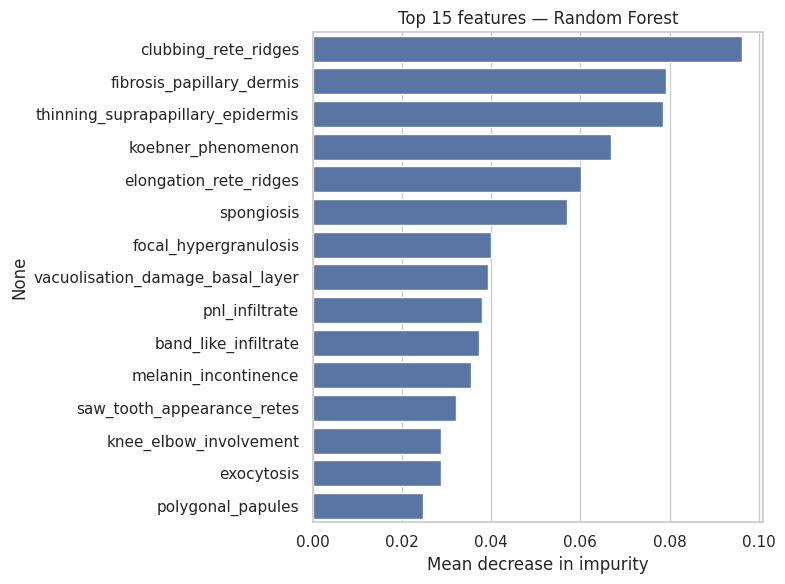

clubbing_rete_ridges                 0.0962
fibrosis_papillary_dermis            0.0793
thinning_suprapapillary_epidermis    0.0785
koebner_phenomenon                   0.0668
elongation_rete_ridges               0.0602
spongiosis                           0.0571
focal_hypergranulosis                0.0400
vacuolisation_damage_basal_layer     0.0393
pnl_infiltrate                       0.0381
band_like_infiltrate                 0.0372
dtype: float64


In [15]:
rf = tuned["Random Forest"].named_steps["clf"]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=imp.head(15).values, y=imp.head(15).index)
plt.xlabel("Mean decrease in impurity")
plt.title("Top 15 features — Random Forest")
plt.tight_layout()
plt.show()

print(imp.head(10).round(4))